# 1. Linear regression

Predicting the sound pressure of an airfoil from six measured characteristics,
using an ordinary least-squares fit as the baseline that every later model is
compared against.

In [1]:
import sys
sys.path.append("..")

import numpy as np

from src.data import load_airfoil_data, prepare_airfoil_xy, airfoil_feature_names
from src.preprocessing import standardise, apply_standardisation, add_intercept
from src.metrics import mse, rsquare, pred
from src.plotting import metrics_table
from src.results import record_result

from src.linear_regression import least_squares

## Loading and standardising the data

The predictors are standardised because they carry different units (displacement
against frequency, for instance), which makes the fitted coefficients directly
comparable and limits the influence of extreme values. Every model in this repo
uses the same standardised features.

In [2]:
train_df, test_df = load_airfoil_data()
feature_names = airfoil_feature_names(train_df)

X_raw, y = prepare_airfoil_xy(train_df)
X_test_raw, y_test = prepare_airfoil_xy(test_df)

# Standardise on the training set, then reuse mu and sigma on the test set so
# both sit on the same scale.
X, mu, sigma = standardise(X_raw)
X_test = apply_standardisation(X_test_raw, mu, sigma)

# A column of ones lets the intercept be fitted as another weight.
X = add_intercept(X)
X_test = add_intercept(X_test)

print(f"train {X.shape}, test {X_test.shape}")
print("features:", feature_names)

train (3890, 7), test (973, 7)
features: ['Frequency', 'Angle', 'Displacement', 'Chord length', 'Velocity', 'Thickness']


## Fitting by least squares

In [3]:
betahat = least_squares(y, X)

y_pred = pred(X, betahat)
train_mse, train_r2 = mse(y, y_pred), rsquare(y, y_pred)

print(f"training MSE      {train_mse:.4f}")
print(f"training R^2      {train_r2:.4f}")

record_result("Least squares", "train", mse=train_mse, r_squared=train_r2)

training MSE      1.8756
training R^2      0.9177


,model,split,mse,r_squared
0,Least squares,train,1.875557,0.917734


In [4]:
y_pred_test = pred(X_test, betahat)
test_mse, test_r2 = mse(y_test, y_pred_test), rsquare(y_test, y_pred_test)

print(f"test MSE          {test_mse:.4f}")
print(f"test R^2          {test_r2:.4f}")

record_result("Least squares", "test", mse=test_mse, r_squared=test_r2)

test MSE          1.9844
test R^2          0.9083


,model,split,mse,r_squared
0,Least squares,test,1.984390,0.908317
1,Least squares,train,1.875557,0.917734


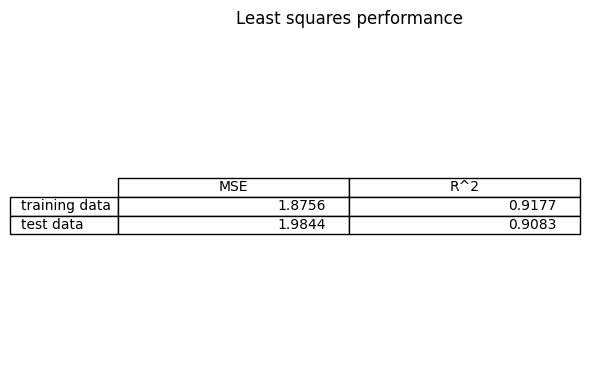

In [5]:
metrics_table(
    [[train_mse, train_r2], [test_mse, test_r2]],
    columns=("MSE", "R^2"),
    row_labels=("training data", "test data"),
    title="Least squares performance",
)

## Fitted coefficients

Because the features are standardised, the magnitude of each coefficient is a
fair indication of how strongly that predictor moves the response.

In [6]:
import pandas as pd

pd.DataFrame(
    {"coefficient": betahat},
    index=["intercept"] + feature_names,
).sort_values("coefficient", key=abs, ascending=False)

,coefficient
intercept,123.970283
Displacement,-3.928647
Frequency,-3.575497
Velocity,1.724957
Angle,0.834478
Chord length,-0.078334
Thickness,-0.013563


## Discussion

The MSE on the training data is smaller than on the test data, so on average the
fit is better on the data it was estimated from. That ordering is expected unless
the model is underfitting; a test MSE *much* larger than the training MSE would
instead point to overfitting, where the model has absorbed noise from the
training sample. Testing the individual coefficients, or inspecting the
covariance matrix for correlated predictors and dropping them, would be the
natural next step if that gap were wide.

The R^2 is close to 1 on both splits, so the model explains most of the
variability in the response. One caveat is that plain R^2 takes no account of how
many parameters the model uses — an adjusted R^2 would penalise the extra
predictors and give a fairer comparison against a simpler model.

**Next:** [02_regularisation_methods.ipynb](02_regularisation_methods.ipynb)